# 1. Meaningful Questions Before Analysis
1. Does gender affect survival rate?
2. Does passenger class influence survival chances?
3. Are younger passengers more likely to survive?
4. How does ticket fare relate to passenger class?
5. Which passenger class had the highest number of passengers?
6. Are there missing values in the dataset?
7. What patterns and anomalies exist in the data?

# 2.Explore Data Structure

In [1]:
import pandas as pd

df = pd.read_csv("C:/Users/MONIKA/Downloads/titanic.csv")

print(df.head())
print(df.info())
print(df.shape)
print(df.describe())

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  
<c

## Check Data Types

In [5]:
print(df.dtypes)

PassengerId      int64
Survived         int64
Pclass           int64
Name               str
Sex                str
Age            float64
SibSp            int64
Parch            int64
Ticket             str
Fare           float64
Cabin              str
Embarked           str
dtype: object


## Check Missing Values

In [6]:
print(df.isnull().sum())

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


# 3.Identify Trends and Patterns

In [8]:
print(df.corr(numeric_only=True))

             PassengerId  Survived    Pclass       Age     SibSp     Parch  \
PassengerId     1.000000 -0.005007 -0.035144  0.036847 -0.057527 -0.001652   
Survived       -0.005007  1.000000 -0.338481 -0.077221 -0.035322  0.081629   
Pclass         -0.035144 -0.338481  1.000000 -0.369226  0.083081  0.018443   
Age             0.036847 -0.077221 -0.369226  1.000000 -0.308247 -0.189119   
SibSp          -0.057527 -0.035322  0.083081 -0.308247  1.000000  0.414838   
Parch          -0.001652  0.081629  0.018443 -0.189119  0.414838  1.000000   
Fare            0.012658  0.257307 -0.549500  0.096067  0.159651  0.216225   

                 Fare  
PassengerId  0.012658  
Survived     0.257307  
Pclass      -0.549500  
Age          0.096067  
SibSp        0.159651  
Parch        0.216225  
Fare         1.000000  


## Survival Distribution

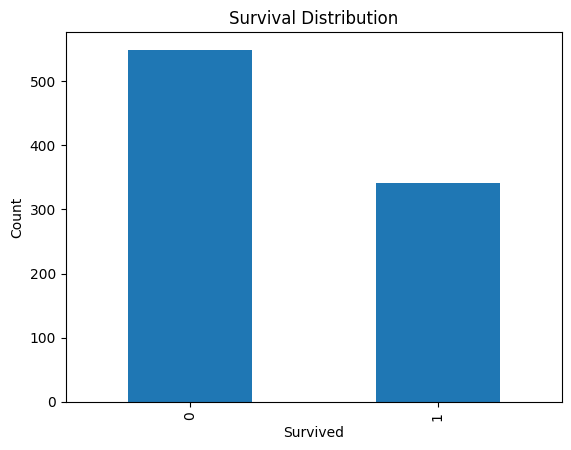

In [9]:
import matplotlib.pyplot as plt

df['Survived'].value_counts().plot(kind='bar')
plt.title("Survival Distribution")
plt.xlabel("Survived")
plt.ylabel("Count")
plt.show()

## Gender vs Survival

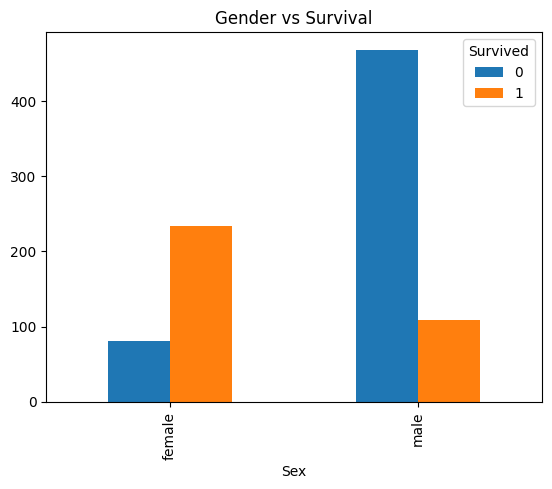

In [10]:
gender_survival = pd.crosstab(df['Sex'], df['Survived'])

gender_survival.plot(kind='bar')
plt.title("Gender vs Survival")
plt.show()

## Passenger Class Distribution

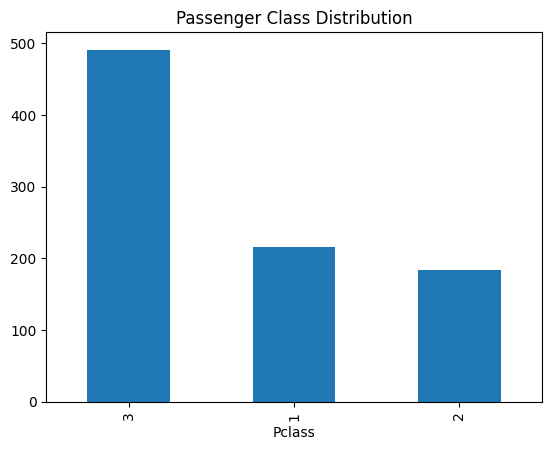

In [11]:
df['Pclass'].value_counts().plot(kind='bar')
plt.title("Passenger Class Distribution")
plt.show()

# 5.Hypothesis Testing

## Hypothesis1
- H0: Gender has no effect on survival
- H1: Gender affects survival

In [12]:
from scipy.stats import chi2_contingency

table = pd.crosstab(df['Sex'], df['Survived'])

chi2, p, dof, expected = chi2_contingency(table)

print("P-value:", p)

if p < 0.05:
    print("Reject H0")
else:
    print("Fail to Reject H0")

P-value: 1.1973570627755645e-58
Reject H0


## Hypothesis2

- H0: Passenger class does not affect survival
- H1: Passenger class affects survival

In [13]:
table = pd.crosstab(df['Pclass'], df['Survived'])

chi2, p, dof, expected = chi2_contingency(table)

print("P-value:", p)

P-value: 4.549251711298793e-23


# 6.Detect Anomalies

## Age Distribution

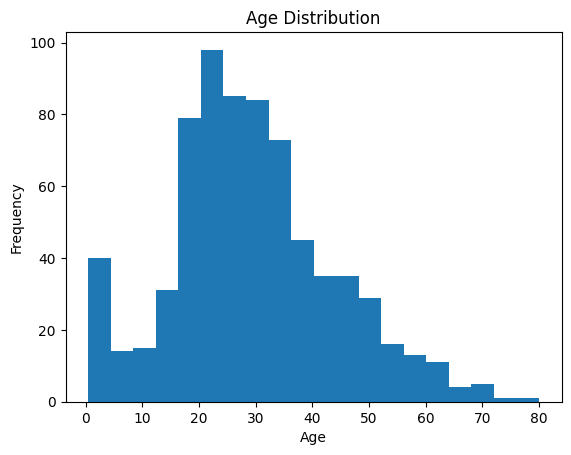

In [14]:
df['Age'].plot(kind='hist', bins=20)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.show()

## Fare Distribution

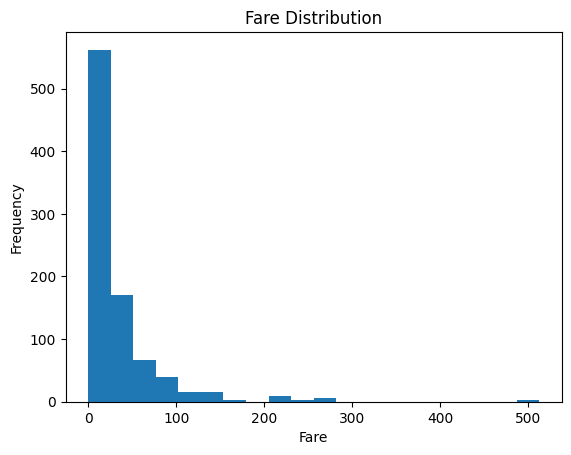

In [15]:
df['Fare'].plot(kind='hist', bins=20)
plt.title("Fare Distribution")
plt.xlabel("Fare")
plt.show()